In [13]:
!pip install transformers datasets accelerate evaluate -q

In [14]:
import pandas as pd
import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)

import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [16]:
fake = pd.read_csv("/content/Fake.csv.zip")
true = pd.read_csv("/content/True.csv.zip")

In [17]:
fake["label"]=0
true["label"]=1

In [18]:
df = pd.concat(
    [fake, true],
    ignore_index=True
)

df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [19]:
print(df["label"].value_counts())

label
0    23481
1    21417
Name: count, dtype: int64


In [20]:
df["content"] = (
    df["title"] + " " + df["text"]
)

df = df[
    ["content", "label"]
]

df.head()

,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1


In [21]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["content"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Training Samples:", len(train_texts))
print("Testing Samples:", len(test_texts))

Training Samples: 35918
Testing Samples: 8980


In [22]:
tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

In [23]:
sample = "I love machine learning"

encoded = tokenizer(sample)

print(encoded)

{'input_ids': [101, 1045, 2293, 3698, 4083, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1]}


In [24]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=256
)

In [25]:
class NewsDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx]
        )

        return item

    def __len__(self):
        return len(self.labels)

In [26]:
train_dataset = NewsDataset(
    train_encodings,
    train_labels
)

test_dataset = NewsDataset(
    test_encodings,
    test_labels
)

In [27]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [28]:
def compute_metrics(pred):

    labels = pred.label_ids

    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            preds,
            average="binary"
        )
    )

    acc = accuracy_score(
        labels,
        preds
    )

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [35]:
training_args = TrainingArguments(
    output_dir="./results",

    num_train_epochs=2,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    weight_decay=0.01,

    logging_dir="./logs",

    logging_steps=100
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [36]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [37]:
trainer.train()

Step,Training Loss
100,0.160116
200,0.024267
300,0.017910
400,0.036017
500,0.011436
600,0.000132
700,0.003921
800,0.022115
900,0.020591
1000,0.000083


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=8980, training_loss=0.009750710194178532, metrics={'train_runtime': 6076.5344, 'train_samples_per_second': 11.822, 'train_steps_per_second': 1.478, 'total_flos': 9450422886420480.0, 'train_loss': 0.009750710194178532, 'epoch': 2.0})

In [38]:
results = trainer.evaluate()

print("\n===== Model Evaluation =====")

print(
    f"Accuracy : {results['eval_accuracy']:.4f}"
)

print(
    f"Precision: {results['eval_precision']:.4f}"
)

print(
    f"Recall   : {results['eval_recall']:.4f}"
)

print(
    f"F1 Score : {results['eval_f1']:.4f}"
)

Training Loss,Validation Loss,Step,Accuracy,Precision,Recall,F1
0.000023,0.000314,8980,0.999777,1.000000,0.999533,0.999767



===== Model Evaluation =====
Accuracy : 0.9998
Precision: 1.0000
Recall   : 0.9995
F1 Score : 0.9998


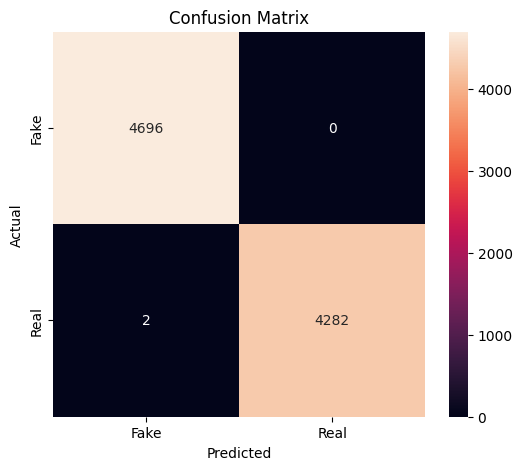

In [39]:
predictions = trainer.predict(
    test_dataset
)

preds = np.argmax(
    predictions.predictions,
    axis=1
)

cm = confusion_matrix(
    test_labels,
    preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Fake','Real'],
    yticklabels=['Fake','Real']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [40]:
model.save_pretrained(
    "fake_news_bert"
)

tokenizer.save_pretrained(
    "fake_news_bert"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('fake_news_bert/tokenizer_config.json', 'fake_news_bert/tokenizer.json')